In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Тренировочный датасет

In [5]:
iris = datasets.load_iris()

data = pd.DataFrame(iris['data'], columns=iris['feature_names'])
data['target'] = pd.Series(iris['target'])

data['target_name'] = data['target'].replace([0, 1, 2], list(iris['target_names']))

In [6]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


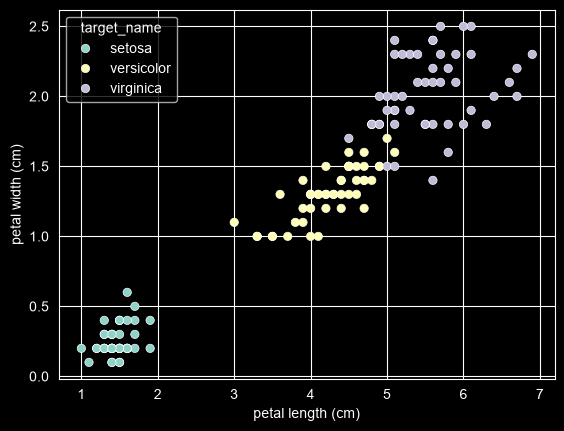

In [7]:
sns.scatterplot(data=data, x='petal length (cm)', y='petal width (cm)', hue='target_name');

In [8]:
features = ['petal length (cm)', 'petal width (cm)']
data = data[features]
data.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


#### Стандартизация данных

In [9]:
st = StandardScaler()
st.fit(data)

data_sc = st.transform(data)

data_sc = st.fit_transform(data)

In [10]:
pd.DataFrame(data_sc, columns=features).head()

,petal length (cm),petal width (cm)
0,-1.340227,-1.315444
1,-1.340227,-1.315444
2,-1.397064,-1.315444
3,-1.283389,-1.315444
4,-1.340227,-1.315444


#### Рассчет главных компонент

In [11]:
pca = PCA()
iris_after_pca = pca.fit_transform(data_sc)

In [12]:
pca_iris = pd.DataFrame(iris_after_pca, columns=['pc1', 'pc2'])
pca_iris.head()

,pc1,pc2
0,-1.877843,-0.017524
1,-1.877843,-0.017524
2,-1.918033,-0.057714
3,-1.837653,0.022666
4,-1.877843,-0.017524


In [13]:
data['target'] = pd.Series(iris['target'])

data['target_name'] = data['target'].replace([0, 1, 2], list(iris['target_names']))

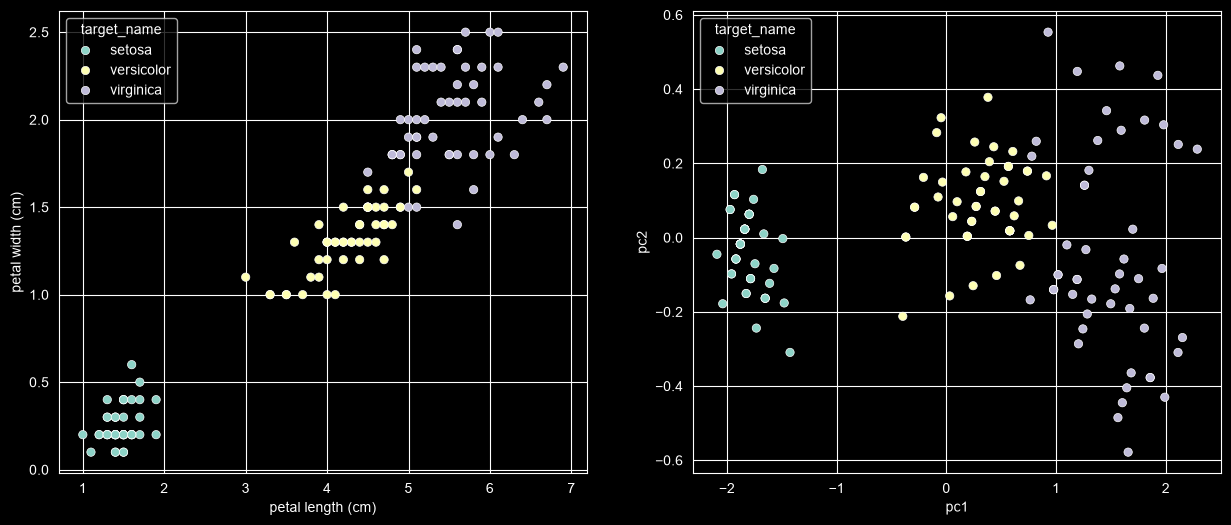

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=data, x='petal length (cm)', y='petal width (cm)', hue=data['target_name'], ax=ax1);
sns.scatterplot(data=pca_iris, x='pc1', y='pc2', hue=data['target_name'], ax=ax2);

In [15]:
pca.components_

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

In [16]:
pc1 = 0.70710678 * data['petal length (cm)'] + 0.70710678 * data['petal width (cm)']
pc2 = -0.70710678 * data['petal length (cm)'] + 0.70710678 * data['petal width (cm)']

In [17]:
pca.explained_variance_ratio_

array([0.98143272, 0.01856728])

### Боевой датасет

In [19]:
data = pd.read_csv('diabetes.csv', index_col=0)
data = data.drop(['Outcome'], axis=1)
data.head()

,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Glucose,,,,,,
148,72,35,0,33.6,0.627,50
85,66,29,0,26.6,0.351,31
183,64,0,0,23.3,0.672,32
89,66,23,94,28.1,0.167,21
137,40,35,168,43.1,2.288,33


In [20]:
data.shape

(768, 6)

#### Стандартизация данных

In [21]:
data_sc = StandardScaler().fit_transform(data)

#### Рассчет главных компонент

In [22]:
pca = PCA()
after_pca = pca.fit_transform(data_sc)

In [23]:
pca.explained_variance_ratio_

array([0.32009165, 0.20680109, 0.15684684, 0.12951006, 0.10611881,
       0.08063156])

In [24]:
pca = PCA(n_components=2)
after_pca_2 = pca.fit_transform(data_sc)

In [25]:
pca.explained_variance_ratio_

array([0.32009165, 0.20680109])

In [26]:
pca = PCA(0.75)
after_pca_75 = pca.fit_transform(data_sc)

In [27]:
pca.explained_variance_ratio_

array([0.32009165, 0.20680109, 0.15684684, 0.12951006])

In [28]:
df = pd.DataFrame(pca.components_, columns=data.columns)
df

,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.346178,0.568482,0.468867,0.496182,0.300220,0.028699
1,0.569355,-0.216544,-0.278028,0.133800,-0.102547,0.723344
2,-0.231283,-0.178553,0.092302,-0.257229,0.853956,0.332716
3,-0.068883,0.078518,0.685809,-0.487489,-0.370844,0.378925


<Axes: >

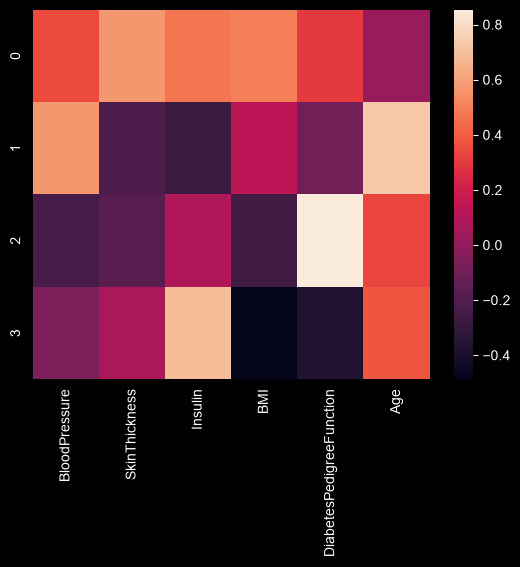

In [29]:
sns.heatmap(df)